# Conditional WGAN-GP sur FWI 28×28 — conditionné sur le mois + tuning FID 


**Différences clés avec un WGAN-GP non conditionnel :**

1. **Conditionnement par le mois (1-12)** : on transforme le WGAN-GP en **cWGAN-GP**. Le générateur prend en entrée `(z, mois)` et apprend à produire une carte FWI cohérente avec le mois donné. Le critic prend `(image, mois)` et doit juger *"est-ce une vraie image de ce mois ?"* — sinon le générateur n'a aucune raison de respecter la condition.
2. **FID custom comme objectif de tuning** : Inception (entraîné sur ImageNet) ne sait pas extraire de features pertinentes sur des cartes FWI. On entraîne donc un **petit autoencodeur convolutif sur le train**, son encodeur sert d'extracteur de features pour calculer une distance de Fréchet. Ce FID custom est calculé **par mois puis moyenné** : ça pénalise un cGAN qui ferait de belles images mais ignorerait le label.

## Plan
1. Imports, données, split temporel
2. Construction des labels mois
3. **Autoencodeur de référence** (très léger) entraîné sur le train, qui fournit l'extracteur de features pour le FID
4. Fonction `compute_fid_conditional(...)` qui calcule le FID par mois puis moyenne
5. Architecture du **cWGAN-GP léger**
6. Entraînement de la version naïve + suivi `val_w_loss` + FID conditionnel sur le valid à chaque epoch
7. Échantillonnage *par mois* depuis le test set
8. **Fine-tuning** : tuner Bayésien avec `FID conditionnel sur valid` comme objectif (à minimiser)
9. Comparaison naïf vs optimisé


In [ ]:
%pip install scipy pandas matplotlib seaborn scikit-learn tensorflow keras-tuner fastparquet

In [ ]:
%pip install "keras-tuner[bayesian]"


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Imports et paramètres

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from scipy.linalg import sqrtm   # pour le FID

# Reproductibilité
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---- Hyperparamètres ----------------------------------------------------
latent_dim    = 32        
batch_size    = 64
epochs        = 40
n_critic      = 3
lambda_gp     = 10.0
num_img       = 12        # 12 mois -> on génère 1 image par mois pour la viz
fit_verbosity = 1

# Constantes data
GRID_SIZE = 28
VALUE_COL = "fwi-daily-proj"
N_MONTHS  = 12

print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {keras.__version__}")
print(f"GPU dispo  : {len(tf.config.list_physical_devices('GPU'))}")

TensorFlow : 2.21.0
Keras      : 3.14.0
GPU dispo  : 0


## 2. Chargement du parquet + split temporel + labels mois

In [ ]:
df_loaded = pd.read_parquet("/Users/matheoleroy/Desktop/genai/fwi_se_spain_28x28.parquet", engine="fastparquet") # à changer si lien avec S23 

df_sorted = df_loaded.sort_values(["time", "lat", "lon"]).reset_index(drop=True)
counts = df_sorted.groupby("time").size()
assert (counts == GRID_SIZE * GRID_SIZE).all()

n_dates = df_sorted["time"].nunique()
X       = df_sorted[VALUE_COL].values.reshape(n_dates, GRID_SIZE, GRID_SIZE)
dates   = np.sort(df_sorted["time"].unique())

# Coords
df_one_date = df_sorted[df_sorted["time"] == df_sorted["time"].iloc[0]]
lats = np.sort(df_one_date["lat"].unique())
lons = np.sort(df_one_date["lon"].unique())
extent = [lons.min(), lons.max(), lats.min(), lats.max()]

print(f"X : {X.shape}")

X : (13149, 28, 28)


In [57]:
# ---- Split temporel + labels mois (0..11) ------------------------------
dates_pd  = pd.to_datetime(dates)
years     = dates_pd.year
months    = dates_pd.month - 1   # 0..11

train_mask = (years >= 1970) & (years <= 2000)
valid_mask = (years >= 2001) & (years <= 2003)
test_mask  = (years >= 2004) & (years <= 2005)

x_train = X[train_mask].astype("float32")
x_valid = X[valid_mask].astype("float32")
x_test  = X[test_mask ].astype("float32")

y_train = months[train_mask].astype("int32").values
y_valid = months[valid_mask].astype("int32").values
y_test  = months[test_mask ].astype("int32").values

train_dates = dates_pd[train_mask]
valid_dates = dates_pd[valid_mask]
test_dates  = dates_pd[test_mask]

# ---- Normalisation [0,1] basée sur le train uniquement ----------------
x_max  = x_train.max()
x_train = x_train / x_max
x_valid = x_valid / x_max
x_test  = x_test  / x_max

# ---- Ajout dim canal ---------------------------------------------------
x_train = x_train[..., np.newaxis]
x_valid = x_valid[..., np.newaxis]
x_test  = x_test[...,  np.newaxis]

month_names = ['Jan','Fev','Mar','Avr','Mai','Juin','Juil','Aout','Sep','Oct','Nov','Dec']

print(f"x_train : {x_train.shape} | y_train : {y_train.shape}")
print(f"x_valid : {x_valid.shape} | y_valid : {y_valid.shape}")
print(f"x_test  : {x_test.shape } | y_test  : {y_test.shape}")
print(f"x_max   = {x_max:.4f}")
print(f"\nRépartition train par mois :")
for m in range(12):
    print(f"  {month_names[m]:5s} : {(y_train==m).sum()}")

x_train : (11323, 28, 28, 1) | y_train : (11323,)
x_valid : (1095, 28, 28, 1) | y_valid : (1095,)
x_test  : (731, 28, 28, 1) | y_test  : (731,)
x_max   = 185.9513

Répartition train par mois :
  Jan   : 961
  Fev   : 876
  Mar   : 961
  Avr   : 930
  Mai   : 961
  Juin  : 930
  Juil  : 961
  Aout  : 961
  Sep   : 930
  Oct   : 961
  Nov   : 930
  Dec   : 961


### Aperçu : un échantillon par mois (train)

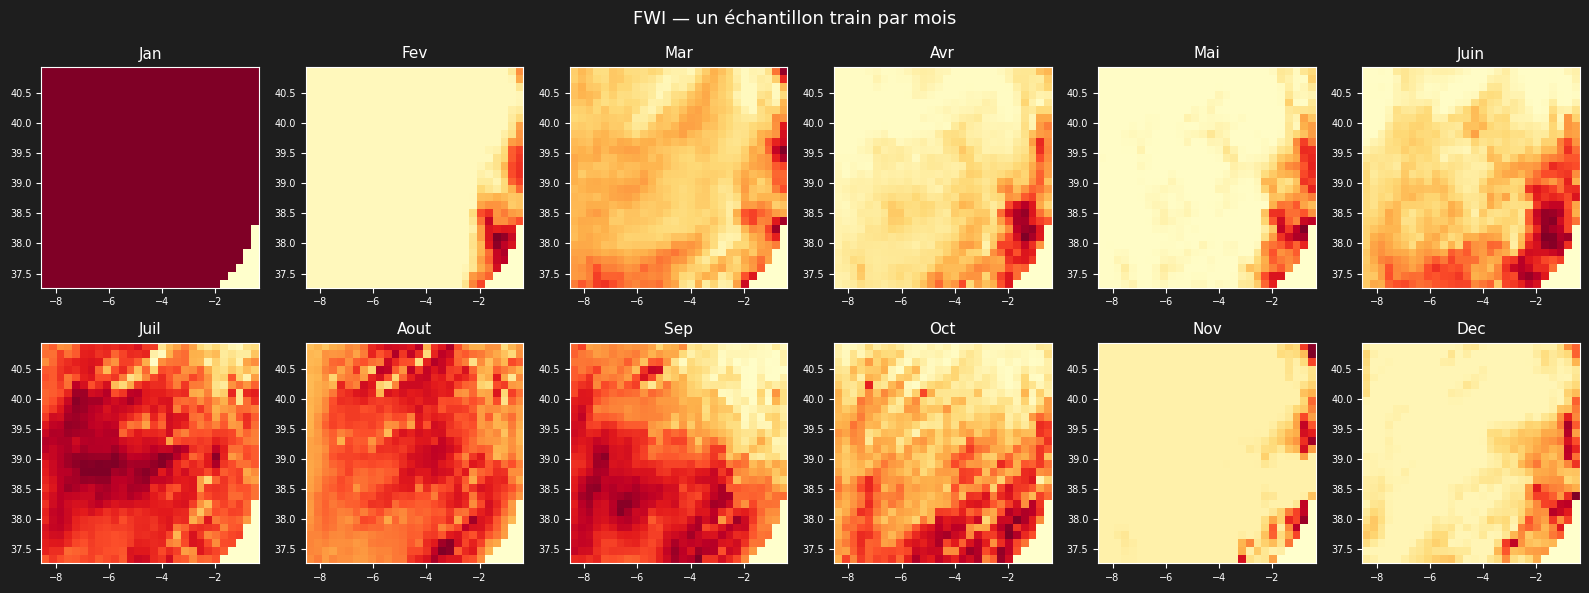

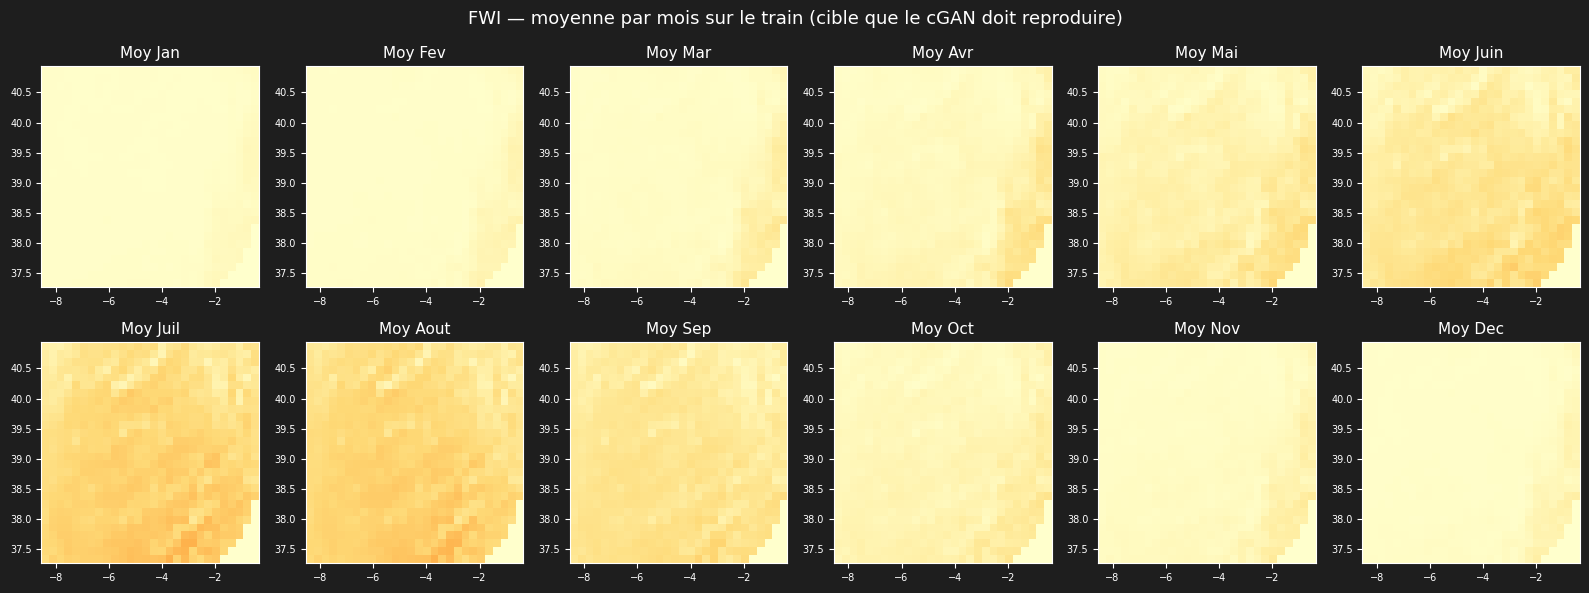

In [58]:
BG = "#1e1e1e"
fig, axes = plt.subplots(2, 6, figsize=(16, 6), facecolor=BG)

for m in range(12):
    ax = axes.ravel()[m]
    ax.set_facecolor(BG)
    # premier exemple disponible pour ce mois
    idx_m = np.where(y_train == m)[0]
    if len(idx_m) == 0:
        ax.axis("off"); continue
    img = x_train[idx_m[0], ..., 0] * x_max
    im = ax.imshow(img, cmap="YlOrRd", origin="lower", extent=extent, aspect="auto")
    ax.set_title(month_names[m], color="white", fontsize=11)
    ax.tick_params(colors="white", labelsize=7)
    for s in ax.spines.values(): s.set_color("white")

plt.suptitle("FWI — un échantillon train par mois", color="white", fontsize=13)
plt.tight_layout()
plt.show()

# Moyenne par mois (utile : montre la saisonnalité que le cGAN doit apprendre)
fig, axes = plt.subplots(2, 6, figsize=(16, 6), facecolor=BG)
for m in range(12):
    ax = axes.ravel()[m]
    ax.set_facecolor(BG)
    mean_m = x_train[y_train == m].mean(axis=0)[..., 0] * x_max
    im = ax.imshow(mean_m, cmap="YlOrRd", origin="lower", extent=extent,
                   aspect="auto", vmin=0, vmax=x_max*0.9)
    ax.set_title(f"Moy {month_names[m]}", color="white", fontsize=11)
    ax.tick_params(colors="white", labelsize=7)
    for s in ax.spines.values(): s.set_color("white")
plt.suptitle("FWI — moyenne par mois sur le train (cible que le cGAN doit reproduire)",
             color="white", fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. Autoencodeur de référence pour le FID

**Pourquoi un AE et pas Inception ?** Le FID standard utilise Inception v3 (entraîné sur ImageNet) comme extracteur de features. Sur des cartes FWI 28×28 monocanal, Inception extrait des features sans rapport avec le contenu (il "voit" ces cartes comme des images étranges). On entraîne donc un petit AE convolutif sur le train, et on utilise **son encodeur** comme extracteur de features pour le FID.

**Caractéristiques :**
- AE volontairement **très léger** — adapté à ~10 k échantillons d'entraînement.
- Bottleneck spatial `7×7×8` (utilisé par le décodeur pour la reconstruction).
- Pour le FID, on extrait une signature compacte via un **`GlobalAveragePooling2D`** sur ce bottleneck → **vecteur de dimension 8** par image. C'est le pattern qu'utilise Inception pour le FID original (avg-pool sur la dernière feature map).
- Entraîné une seule fois, puis **gelé** pour tous les calculs de FID.


In [ ]:
def build_autoencoder():
    """
    AE convolutif léger (~14 k params).

    Renvoie deux modèles :
      - autoencoder : entrée (28,28,1) -> reconstruction (28,28,1)
      - encoder     : entrée (28,28,1) -> features 1D de dim FEATURE_DIM
                      (utilisé pour le FID, sortie compatible np.cov).
    """
    # ---- Encoder (partagé) ----
    inp = keras.Input(shape=(28, 28, 1))
    e = layers.Conv2D(16, 3, strides=2, padding="same", activation="relu")(inp)  # 14x14x16
    e = layers.Conv2D(24, 3, strides=2, padding="same", activation="relu")(e)    #  7x7x24
    z_spatial = layers.Conv2D(16, 3, padding="same", activation="relu",
                              name="bottleneck")(e)                              #  7x7x16

    # ---- Decoder (utilise le bottleneck spatial) ----
    d = layers.Conv2DTranspose(24, 3, strides=2, padding="same",
                               activation="relu")(z_spatial)                     # 14x14x24
    d = layers.Conv2DTranspose(16, 3, strides=2, padding="same",
                               activation="relu")(d)                             # 28x28x16
    out = layers.Conv2D(1, 3, padding="same", activation="sigmoid")(d)

    autoencoder = keras.Model(inp, out, name="autoencoder")

    # ---- Encoder pour FID : GAP sur le bottleneck -> vecteur (N, 16) ----
    z_pooled = layers.GlobalAveragePooling2D(name="features")(z_spatial)
    encoder  = keras.Model(inp, z_pooled, name="encoder")

    return autoencoder, encoder

autoencoder, encoder = build_autoencoder()
autoencoder.compile(optimizer="adam", loss="mse")

print("=== Autoencoder ===")
autoencoder.summary()
print("\n=== Encoder pour FID (sortie 1D) ===")
encoder.summary()

FEATURE_DIM = encoder.output_shape[-1]
print(f"\nDim des features pour FID : {FEATURE_DIM}")


=== Autoencoder ===


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 14, 14, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 7, 7, 24)       │         3,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Conv2D)             │ (None, 7, 7, 16)       │         3,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 14, 14, 24)     │         3,480 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 28, 28, 16)     │         3,472 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,209 (55.50 KB)

 Trainable params: 14,209 (55.50 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 14, 14, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 7, 7, 24)       │         3,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Conv2D)             │ (None, 7, 7, 16)       │         3,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ features                        │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,112 (27.78 KB)

 Trainable params: 7,112 (27.78 KB)

 Non-trainable params: 0 (0.00 B)


Dim des features pour FID : 16


Epoch 1/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0540 - val_loss: 0.0139
Epoch 2/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0169 - val_loss: 0.0139
Epoch 3/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0169 - val_loss: 0.0139
Epoch 4/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0168 - val_loss: 0.0139
Epoch 5/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0155 - val_loss: 0.0036
Epoch 6/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0016 - val_loss: 9.0728e-04
Epoch 7/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.5987e-04 - val_loss: 7.3148e-04
Epoch 8/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.1162e-04 - val_loss: 6.1320e-04
Epoch 9/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.8398e-04 - val_loss: 5.1541e-04
Epoch 10/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5.0729e-04 - val_loss: 4.6418e-04
Epoch 11/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 4.6093e-04 - val_loss: 4.4620e-04
Epoch 12/20
89/89 ━

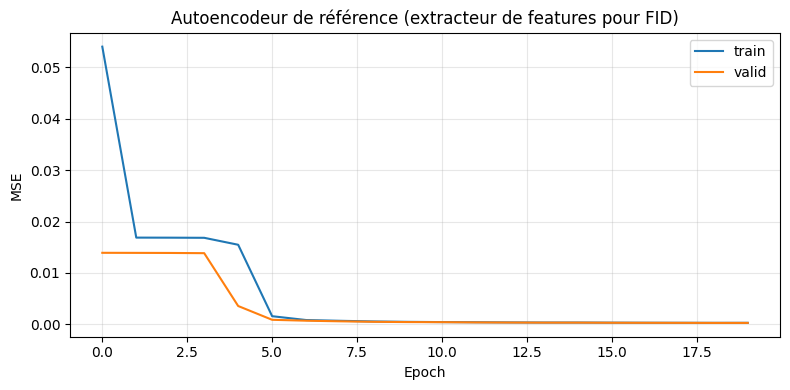


Encodeur gelé. Sortie features de dim : 16


In [ ]:
# Entraînement de l'AE (rapide : 20 epochs suffisent)
ae_history = autoencoder.fit(
    x_train, x_train,
    validation_data=(x_valid, x_valid),
    epochs=20, batch_size=128, verbose=1,
)

# Plot loss AE
plt.figure(figsize=(8, 4))
plt.plot(ae_history.history["loss"],     label="train")
plt.plot(ae_history.history["val_loss"], label="valid")
plt.xlabel("Epoch"); plt.ylabel("MSE")
plt.title("Autoencodeur de référence (extracteur de features pour FID)")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# On gèle l'encodeur — il ne sera plus jamais ré-entraîné.
for layer in encoder.layers:
    layer.trainable = False
encoder.trainable = False

print(f"\nEncodeur gelé. Sortie features de dim : {encoder.output_shape[-1]}")


### 3.1 Vérification : reconstructions de l'AE sur le test
Si les reconstructions sont fidèles, l'encodeur capture bien l'info pertinente — il sera un bon extracteur pour le FID.

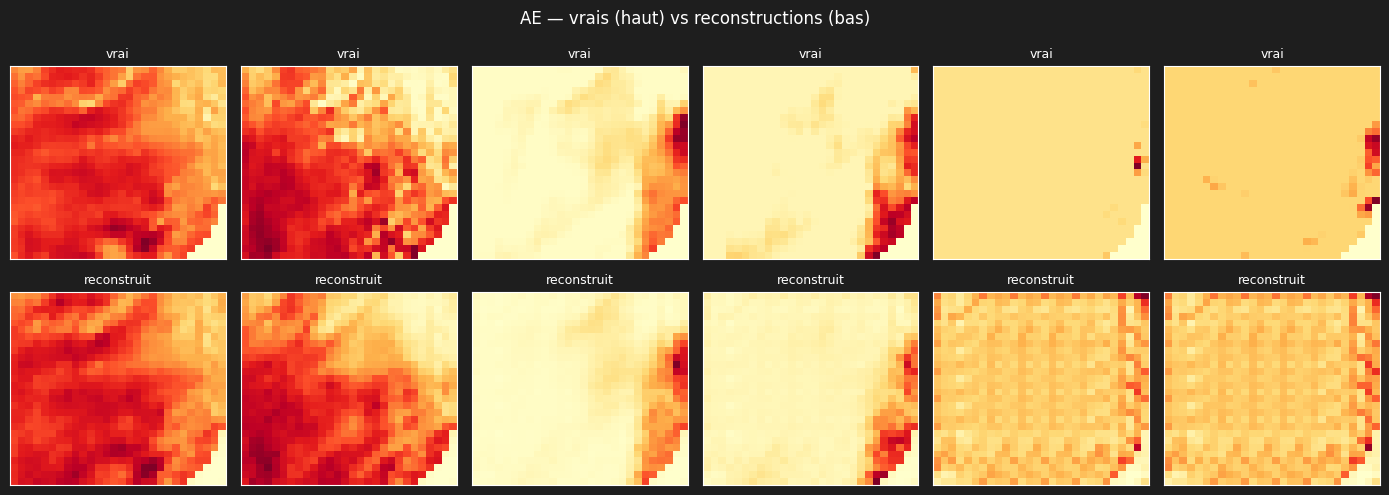

In [62]:
np.random.seed(0)
idx = np.random.choice(len(x_test), 6, replace=False)
real = x_test[idx]
recon = autoencoder.predict(real, verbose=0)

fig, axes = plt.subplots(2, 6, figsize=(14, 5), facecolor=BG)
for i in range(6):
    for row, img in enumerate([real[i, ..., 0], recon[i, ..., 0]]):
        ax = axes[row, i]; ax.set_facecolor(BG)
        ax.imshow(img * x_max, cmap="YlOrRd", origin="lower", extent=extent, aspect="auto")
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values(): s.set_color("white")
    axes[0, i].set_title(f"vrai", color="white", fontsize=9)
    axes[1, i].set_title("reconstruit", color="white", fontsize=9)
plt.suptitle("AE — vrais (haut) vs reconstructions (bas)", color="white")
plt.tight_layout(); plt.show()

## 4. Fonction FID conditionnel

**FID standard** entre deux distributions $P_r, P_g$ représentées par leurs features moyennes $\mu_r, \mu_g$ et covariances $\Sigma_r, \Sigma_g$ :

$$\text{FID} = \|\mu_r - \mu_g\|_2^2 + \mathrm{Tr}\big(\Sigma_r + \Sigma_g - 2(\Sigma_r \Sigma_g)^{1/2}\big)$$

**FID conditionnel** : on calcule un FID **par mois** (entre les vraies images de ce mois et les fausses générées avec ce label), puis on **moyenne** sur les 12 mois. Avantage : un cGAN qui produirait toujours la même belle image quelle que soit la condition aurait un bon FID global mais un mauvais FID conditionnel.

In [ ]:
def _fid_from_features(feat_real, feat_fake, eps=1e-6):
    """
    Calcule la FID entre deux ensembles de vecteurs de features de forme (N, d).

    Attendu : feat_real et feat_fake sont des np.ndarray 2D.
    """
    # Garde-fou 
    if feat_real.ndim > 2:
        feat_real = feat_real.reshape(feat_real.shape[0], -1)
    if feat_fake.ndim > 2:
        feat_fake = feat_fake.reshape(feat_fake.shape[0], -1)

    mu_r, sigma_r = feat_real.mean(axis=0), np.cov(feat_real, rowvar=False)
    mu_g, sigma_g = feat_fake.mean(axis=0), np.cov(feat_fake, rowvar=False)

    sigma_r = np.atleast_2d(sigma_r)
    sigma_g = np.atleast_2d(sigma_g)

    diff = mu_r - mu_g
    # Régularisation pour éviter les matrices singulières
    sigma_r = sigma_r + np.eye(sigma_r.shape[0]) * eps
    sigma_g = sigma_g + np.eye(sigma_g.shape[0]) * eps

    covmean, _ = sqrtm(sigma_r @ sigma_g, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = float(diff @ diff + np.trace(sigma_r + sigma_g - 2 * covmean))
    return fid


def compute_features(images, encoder, batch_size=256):
    """
    Passe les images dans l'encodeur, renvoie un array (N, FEATURE_DIM)
    en float64 pour la stabilité numérique du calcul de cov.
    """
    feats = encoder.predict(images, batch_size=batch_size, verbose=0)
    # Si l'encodeur sort un tenseur spatial, on aplatit (sécurité).
    if feats.ndim > 2:
        feats = feats.reshape(feats.shape[0], -1)
    return feats.astype("float64")


def compute_fid_conditional(generator, encoder, x_real, y_real, latent_dim,
                            n_samples_per_class=None, min_per_class=20):
    """
    Calcule la FID moyenne par mois entre x_real (avec labels y_real)
    et des images générées avec les mêmes labels.

    n_samples_per_class : si fourni, génère ce nb d'images par classe ;
                         sinon génère autant que le nb de vrais échantillons disponibles.

    Renvoie (fid_mean, dict_fid_par_mois).
    """
    fids = {}
    for m in range(N_MONTHS):
        idx = np.where(y_real == m)[0]
        if len(idx) < min_per_class:
            continue   # pas assez de vrais échantillons pour estimer la covariance
        real_m = x_real[idx]

        n_gen  = n_samples_per_class if n_samples_per_class else len(idx)
        z      = tf.random.normal((n_gen, latent_dim))
        labels = tf.constant([m] * n_gen, dtype=tf.int32)
        fake_m = generator([z, labels], training=False).numpy()

        feat_r = compute_features(real_m, encoder)
        feat_f = compute_features(fake_m, encoder)
        fids[m] = _fid_from_features(feat_r, feat_f)

    fid_mean = float(np.mean(list(fids.values()))) if fids else float("inf")
    return fid_mean, fids


# Sanity-check : FID(real, real) doit être ~0 (avec un epsilon de régularisation).
print("Sanity-check : FID(test, test) sur features AE (devrait être ~0)")
feat = compute_features(x_test, encoder)
print(f"  -> {_fid_from_features(feat, feat):.6f}")
print(f"  shape des features : {feat.shape}  (doit être 2D : (N, {FEATURE_DIM}))")


Sanity-check : FID(test, test) sur features AE (devrait être ~0)
  -> -0.000000
  shape des features : (731, 16)  (doit être 2D : (N, 16))


/var/folders/3k/gpr62wcn3h7dyfkv8l9fcsl00000gn/T/ipykernel_26075/2814829722.py:25: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = sqrtm(sigma_r @ sigma_g, disp=False)


## 5. Architecture du cWGAN-GP

### 5.1 Critic conditionnel
Le critic prend `(image, label_mois)`. On embed le label en un vecteur de 16 dims, on le **broadcast spatialement** en une feature map 28×28×16, et on **concatène avec l'image d'entrée**. 

In [64]:
def build_cond_discriminator(n_classes=N_MONTHS, embed_dim=16):
    img_in   = keras.Input(shape=(28, 28, 1), name="img")
    label_in = keras.Input(shape=(), dtype="int32", name="label")

    # Embedding du label puis broadcast en feature map 28x28xembed_dim
    e = layers.Embedding(n_classes, embed_dim)(label_in)               # (B, embed_dim)
    e = layers.Reshape((1, 1, embed_dim))(e)
    e = layers.UpSampling2D(size=(28, 28))(e)                          # (B, 28, 28, embed_dim)

    x = layers.Concatenate()([img_in, e])                              # (B, 28, 28, 1+embed_dim)
    x = layers.Conv2D(16, 4, strides=2, padding="same")(x)             # 14x14
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(32, 4, strides=2, padding="same")(x)             # 7x7
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1)(x)
    return keras.Model([img_in, label_in], out, name="cond_critic")

cond_disc = build_cond_discriminator()
cond_disc.summary()

Model: "cond_critic"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label (InputLayer)  │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_16        │ (None, 16)        │        192 │ label[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_16          │ (None, 1, 1, 16)  │          0 │ embedding_16[0][… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img (InputLayer)    │ (None, 28, 28, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_24    │ (None, 28, 28,    │          0 │ reshape_16[0][0]  │
│ (UpSampling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_16      │ (None, 28, 28,    │          0 │ img[0][0],        │
│ (Concatenate)       │ 17)               │            │ up_sampling2d_24… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_55 (Conv2D)  │ (None, 14, 14,    │      4,368 │ concatenate_16[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_40      │ (None, 14, 14,    │          0 │ conv2d_55[0][0]   │
│ (LeakyReLU)         │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_56 (Conv2D)  │ (None, 7, 7, 32)  │      8,224 │ leaky_re_lu_40[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_41      │ (None, 7, 7, 32)  │          0 │ conv2d_56[0][0]   │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_8 (Flatten) │ (None, 1568)      │          0 │ leaky_re_lu_41[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 1568)      │          0 │ flatten_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 1)         │      1,569 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,353 (56.07 KB)

 Trainable params: 14,353 (56.07 KB)

 Non-trainable params: 0 (0.00 B)

### 5.2 Générateur conditionnel
Le générateur prend `(z, label)`. On embed le label en un vecteur, on le concatène à `z`, puis on déroule l'architecture habituelle.

In [65]:
def build_cond_generator(latent_dim, n_classes=N_MONTHS, embed_dim=16):
    z_in     = keras.Input(shape=(latent_dim,), name="z")
    label_in = keras.Input(shape=(), dtype="int32", name="label")

    e = layers.Embedding(n_classes, embed_dim)(label_in)               # (B, embed_dim)
    h = layers.Concatenate()([z_in, e])                                # (B, latent+embed)

    x = layers.Dense(7 * 7 * 32)(h)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Reshape((7, 7, 32))(x)

    x = layers.UpSampling2D()(x)                                       # 14x14
    x = layers.Conv2D(32, 3, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.UpSampling2D()(x)                                       # 28x28
    x = layers.Conv2D(16, 3, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)

    out = layers.Conv2D(1, 5, padding="same", activation="sigmoid")(x)
    return keras.Model([z_in, label_in], out, name="cond_generator")

cond_gen = build_cond_generator(latent_dim)
cond_gen.summary()

Model: "cond_generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label (InputLayer)  │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (InputLayer)      │ (None, 32)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_17        │ (None, 16)        │        192 │ label[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_17      │ (None, 48)        │          0 │ z[0][0],          │
│ (Concatenate)       │                   │            │ embedding_17[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 1568)      │     76,832 │ concatenate_17[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_42      │ (None, 1568)      │          0 │ dense_17[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_17          │ (None, 7, 7, 32)  │          0 │ leaky_re_lu_42[0… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_25    │ (None, 14, 14,    │          0 │ reshape_17[0][0]  │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_57 (Conv2D)  │ (None, 14, 14,    │      9,248 │ up_sampling2d_25… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_43      │ (None, 14, 14,    │          0 │ conv2d_57[0][0]   │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_26    │ (None, 28, 28,    │          0 │ leaky_re_lu_43[0… │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_58 (Conv2D)  │ (None, 28, 28,    │      4,624 │ up_sampling2d_26… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_44      │ (None, 28, 28,    │          0 │ conv2d_58[0][0]   │
│ (LeakyReLU)         │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_59 (Conv2D)  │ (None, 28, 28, 1) │        401 │ leaky_re_lu_44[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 91,297 (356.63 KB)

 Trainable params: 91,297 (356.63 KB)

 Non-trainable params: 0 (0.00 B)

### 5.3 Classe `CondWGANGP`

Différences clés avec le notebook précédent :
- `train_step` reçoit maintenant un **tuple `(images, labels)`**.
- Les fakes sont générés avec **les mêmes labels** que les vraies images du batch (sinon le critic ne peut pas comparer).
- Le gradient penalty est calculé sur des interpolations conditionnées sur les labels du batch.

In [ ]:
class CondWGANGP(keras.Model):
    # cWGAN-GP : conditionnement par embedding concatene au latent / a l'image.

    def __init__(self, discriminator, generator, latent_dim=32,
                 n_critic=3, lambda_gp=10.0, **kwargs):
        super().__init__(**kwargs)
        self.discriminator = discriminator
        self.generator     = generator
        self.latent_dim    = latent_dim
        self.n_critic      = n_critic
        self.lambda_gp     = lambda_gp

    def call(self, inputs):
        # inputs = (z, labels)
        return self.generator(inputs)

    def compile(self, d_optimizer, g_optimizer):
        super().compile()
        self.d_optimizer   = d_optimizer
        self.g_optimizer   = g_optimizer
        self.d_loss_metric = keras.metrics.Mean(name="d_loss")
        self.g_loss_metric = keras.metrics.Mean(name="g_loss")
        self.w_loss_metric = keras.metrics.Mean(name="w_loss")

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric, self.w_loss_metric]

    # ---- Gradient penalty conditionnel ------------------------------------
    def gradient_penalty(self, batch_size, real_images, fake_images, labels):
        epsilon = tf.random.uniform([batch_size, 1, 1, 1], 0.0, 1.0)
        interpolated = epsilon * real_images + (1 - epsilon) * fake_images
        with tf.GradientTape() as gp_tape:
            gp_tape.watch(interpolated)
            interp_critics = self.discriminator([interpolated, labels], training=True)
        grads = gp_tape.gradient(interp_critics, [interpolated])[0]
        norm  = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1, 2, 3]) + 1e-12)
        return self.lambda_gp * tf.reduce_mean((norm - 1.0) ** 2)

    # ---- Train step -------------------------------------------------------
    def train_step(self, data):
        # data est un tuple (images, labels) 
        if isinstance(data, tuple):
            real_images, labels = data
        else:
            real_images, labels = data[0], data[1]
        labels = tf.cast(labels, tf.int32)
        batch_size = tf.shape(real_images)[0]

        # n_critic updates du critic
        for _ in range(self.n_critic):
            z = tf.random.normal((batch_size, self.latent_dim))
            with tf.GradientTape() as tape:
                fake_images  = self.generator([z, labels], training=True)
                fake_critics = self.discriminator([fake_images, labels],  training=True)
                real_critics = self.discriminator([real_images, labels],  training=True)
                w_loss = tf.reduce_mean(fake_critics) - tf.reduce_mean(real_critics)
                gp     = self.gradient_penalty(batch_size, real_images, fake_images, labels)
                d_loss = w_loss + gp
            d_grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
            self.d_optimizer.apply_gradients(zip(d_grads, self.discriminator.trainable_weights))

        # 1 update du generator
        z = tf.random.normal((batch_size, self.latent_dim))
        with tf.GradientTape() as tape:
            fake_images  = self.generator([z, labels], training=True)
            fake_critics = self.discriminator([fake_images, labels], training=True)
            g_loss = -tf.reduce_mean(fake_critics)
        g_grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(g_grads, self.generator.trainable_weights))

        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)
        self.w_loss_metric.update_state(w_loss)
        return {"d_loss": self.d_loss_metric.result(),
                "g_loss": self.g_loss_metric.result(),
                "w_loss": self.w_loss_metric.result()}

    # ---- Validation step (sans GP, sans backprop) ------------------------
    def test_step(self, data):
        if isinstance(data, tuple):
            real_images, labels = data
        else:
            real_images, labels = data[0], data[1]
        labels = tf.cast(labels, tf.int32)
        batch_size = tf.shape(real_images)[0]

        z            = tf.random.normal((batch_size, self.latent_dim))
        fake_images  = self.generator([z, labels], training=False)
        fake_critics = self.discriminator([fake_images, labels], training=False)
        real_critics = self.discriminator([real_images, labels], training=False)

        w_loss = tf.reduce_mean(fake_critics) - tf.reduce_mean(real_critics)
        g_loss = -tf.reduce_mean(fake_critics)

        self.w_loss_metric.update_state(w_loss)
        self.g_loss_metric.update_state(g_loss)
        self.d_loss_metric.update_state(w_loss)
        return {"d_loss": self.d_loss_metric.result(),
                "g_loss": self.g_loss_metric.result(),
                "w_loss": self.w_loss_metric.result()}

### 5.4 Callbacks : sauvegarde d'images par mois + FID conditionnel sur le valid

In [ ]:
class CondImagesCallback(keras.callbacks.Callback):
    # Sauve 1 image generee par mois a chaque epoch (z fixes pour suivre l'evolution).

    def __init__(self, latent_dim, run_dir="./run_cond", x_max=1.0, extent=None, seed=0):
        super().__init__()
        self.latent_dim = latent_dim
        self.run_dir    = run_dir
        self.x_max      = x_max
        self.extent     = extent
        os.makedirs(run_dir, exist_ok=True)
        rng = np.random.default_rng(seed)
        self.fixed_z      = rng.normal(size=(N_MONTHS, latent_dim)).astype("float32")
        self.fixed_labels = np.arange(N_MONTHS, dtype="int32")

    def on_epoch_end(self, epoch, logs=None):
        gen = self.model.generator(
            [tf.constant(self.fixed_z), tf.constant(self.fixed_labels)],
            training=False
        ).numpy()

        fig, axes = plt.subplots(2, 6, figsize=(14, 5), facecolor="#1e1e1e")
        for m in range(N_MONTHS):
            ax = axes.ravel()[m]; ax.set_facecolor("#1e1e1e")
            img = gen[m, ..., 0] * self.x_max
            ax.imshow(img, cmap="YlOrRd", origin="lower",
                      extent=self.extent, aspect="auto")
            ax.set_title(month_names[m], color="white", fontsize=9)
            ax.set_xticks([]); ax.set_yticks([])
            for s in ax.spines.values(): s.set_color("white")
        plt.suptitle(f"Epoch {epoch+1:03d} — 1 image générée par mois",
                     color="white", fontsize=11)
        plt.tight_layout()
        plt.savefig(f"{self.run_dir}/epoch_{epoch+1:03d}.png",
                    facecolor="#1e1e1e", dpi=80)
        plt.close(fig)


class FIDCallback(keras.callbacks.Callback):
    # Calcule le FID conditionnel sur le valid set tous les `every` epochs.
    # Stocke les valeurs dans self.fids (liste).

    def __init__(self, encoder, x_valid, y_valid, latent_dim, every=2, n_per_class=200):
        super().__init__()
        self.encoder     = encoder
        self.x_valid     = x_valid
        self.y_valid     = y_valid
        self.latent_dim  = latent_dim
        self.every       = every
        self.n_per_class = n_per_class
        self.fids        = []        # liste de dicts {"epoch": e, "fid_mean": ...}

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every != 0:
            return
        fid_mean, _ = compute_fid_conditional(
            self.model.generator, self.encoder,
            self.x_valid, self.y_valid, self.latent_dim,
            n_samples_per_class=self.n_per_class,
        )
        self.fids.append({"epoch": epoch + 1, "fid_mean": fid_mean})
        if logs is not None:
            logs["val_fid_cond"] = fid_mean
        print(f"  [FIDCallback] epoch {epoch+1} : FID conditionnel valid = {fid_mean:.3f}")

## 6. Entraînement du cWGAN-GP naïf

Pour passer `(images, labels)` à `.fit()` avec un GAN conditionnel, on utilise un `tf.data.Dataset`. Keras le décomposera en `(real_images, labels)` dans `train_step`.

In [68]:
# tf.data.Dataset pour train et valid
train_ds = (tf.data.Dataset.from_tensor_slices((x_train, y_train))
            .shuffle(buffer_size=2048, seed=SEED)
            .batch(batch_size, drop_remainder=True)
            .prefetch(tf.data.AUTOTUNE))

valid_ds = (tf.data.Dataset.from_tensor_slices((x_valid, y_valid))
            .batch(batch_size, drop_remainder=True)
            .prefetch(tf.data.AUTOTUNE))

print(f"train_ds : {len(list(train_ds))} batches de {batch_size}")
print(f"valid_ds : {len(list(valid_ds))} batches de {batch_size}")

train_ds : 176 batches de 64
valid_ds : 17 batches de 64


In [69]:
# (re)build pour partir frais
cond_disc = build_cond_discriminator()
cond_gen  = build_cond_generator(latent_dim)

cgan = CondWGANGP(
    discriminator=cond_disc, generator=cond_gen,
    latent_dim=latent_dim, n_critic=n_critic, lambda_gp=lambda_gp,
)
cgan.compile(
    d_optimizer = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5, beta_2=0.9),
    g_optimizer = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5, beta_2=0.9),
)

img_cb = CondImagesCallback(latent_dim=latent_dim, run_dir="./run_cond_naive",
                            x_max=x_max, extent=extent)
fid_cb = FIDCallback(encoder, x_valid, y_valid, latent_dim, every=2, n_per_class=200)

history = cgan.fit(
    train_ds,
    validation_data = valid_ds,
    epochs          = epochs,
    callbacks       = [img_cb, fid_cb],
    verbose         = fit_verbosity,
)

Epoch 1/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 17s 81ms/step - d_loss: -0.0202 - g_loss: 1.8812 - w_loss: -0.8145 - val_d_loss: -1.4079 - val_g_loss: 4.4090 - val_w_loss: -1.4079
Epoch 2/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - d_loss: -1.4973 - g_loss: 2.3763 - w_loss: -1.6348

/var/folders/3k/gpr62wcn3h7dyfkv8l9fcsl00000gn/T/ipykernel_26075/2814829722.py:25: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = sqrtm(sigma_r @ sigma_g, disp=False)


  [FIDCallback] epoch 2 : FID conditionnel valid = 1.982
176/176 ━━━━━━━━━━━━━━━━━━━━ 15s 86ms/step - d_loss: -1.2056 - g_loss: 0.1723 - w_loss: -1.3556 - val_d_loss: -0.5898 - val_g_loss: 0.7493 - val_w_loss: -0.5898 - val_fid_cond: 1.9818
Epoch 3/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - d_loss: -0.3923 - g_loss: 0.1838 - w_loss: -0.4413 - val_d_loss: -0.2865 - val_g_loss: 1.5565 - val_w_loss: -0.2865
Epoch 4/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - d_loss: -0.3172 - g_loss: 2.1751 - w_loss: -0.3534  [FIDCallback] epoch 4 : FID conditionnel valid = 0.953
176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 91ms/step - d_loss: -0.3129 - g_loss: 2.4484 - w_loss: -0.3440 - val_d_loss: -0.2720 - val_g_loss: 3.5322 - val_w_loss: -0.2720 - val_fid_cond: 0.9529
Epoch 5/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 15s 87ms/step - d_loss: -0.3163 - g_loss: 2.6363 - w_loss: -0.3457 - val_d_loss: -0.4220 - val_g_loss: 2.9517 - val_w_loss: -0.4220
Epoch 6/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - d_loss: -0.297

In [70]:
generator_path = "../fwi_generator_cwgangp.keras"
cgan.generator.save(generator_path)
print(f"Générateur sauvegardé sous : {generator_path}")


Générateur sauvegardé sous : ../fwi_generator_cwgangp.keras


### 6.1 Loss train/valid + courbe FID conditionnel

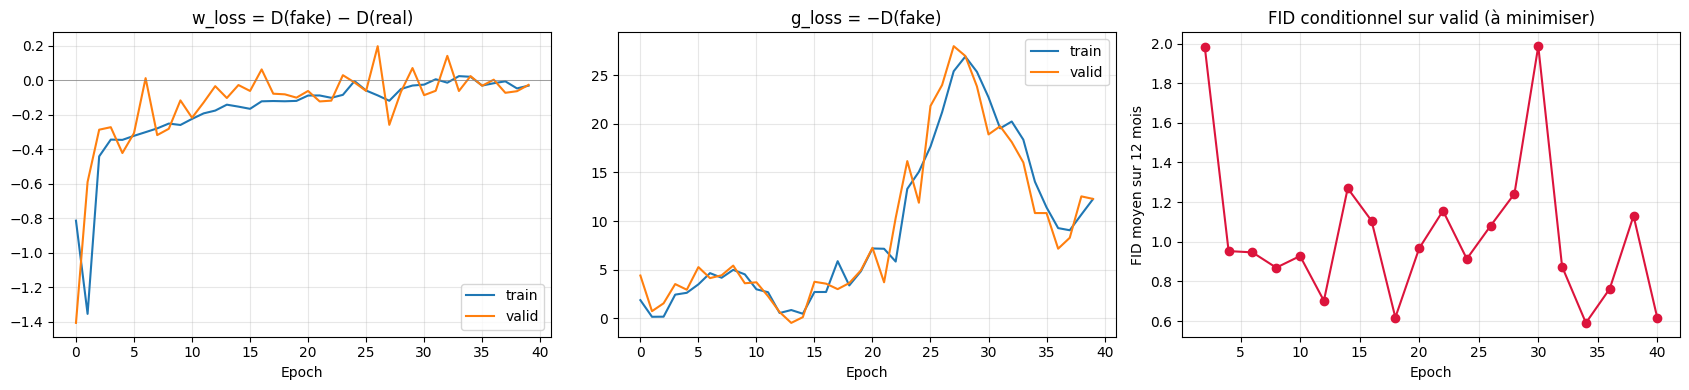


FID conditionnel valid final : 0.614


In [71]:
h = history.history
fid_log = fid_cb.fids   # [{"epoch": e, "fid_mean": ...}, ...]

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].plot(h["w_loss"],     label="train")
if "val_w_loss" in h:
    axes[0].plot(h["val_w_loss"], label="valid")
axes[0].set_title("w_loss = D(fake) − D(real)")
axes[0].set_xlabel("Epoch"); axes[0].axhline(0, color="grey", lw=0.5)
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(h["g_loss"],     label="train")
if "val_g_loss" in h:
    axes[1].plot(h["val_g_loss"], label="valid")
axes[1].set_title("g_loss = −D(fake)")
axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)

if fid_log:
    axes[2].plot([f["epoch"] for f in fid_log],
                 [f["fid_mean"] for f in fid_log], marker="o", color="crimson")
    axes[2].set_title("FID conditionnel sur valid (à minimiser)")
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("FID moyen sur 12 mois")
    axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

if fid_log:
    print(f"\nFID conditionnel valid final : {fid_log[-1]['fid_mean']:.3f}")

### 6.2 Évolution des images générées au fil des epochs

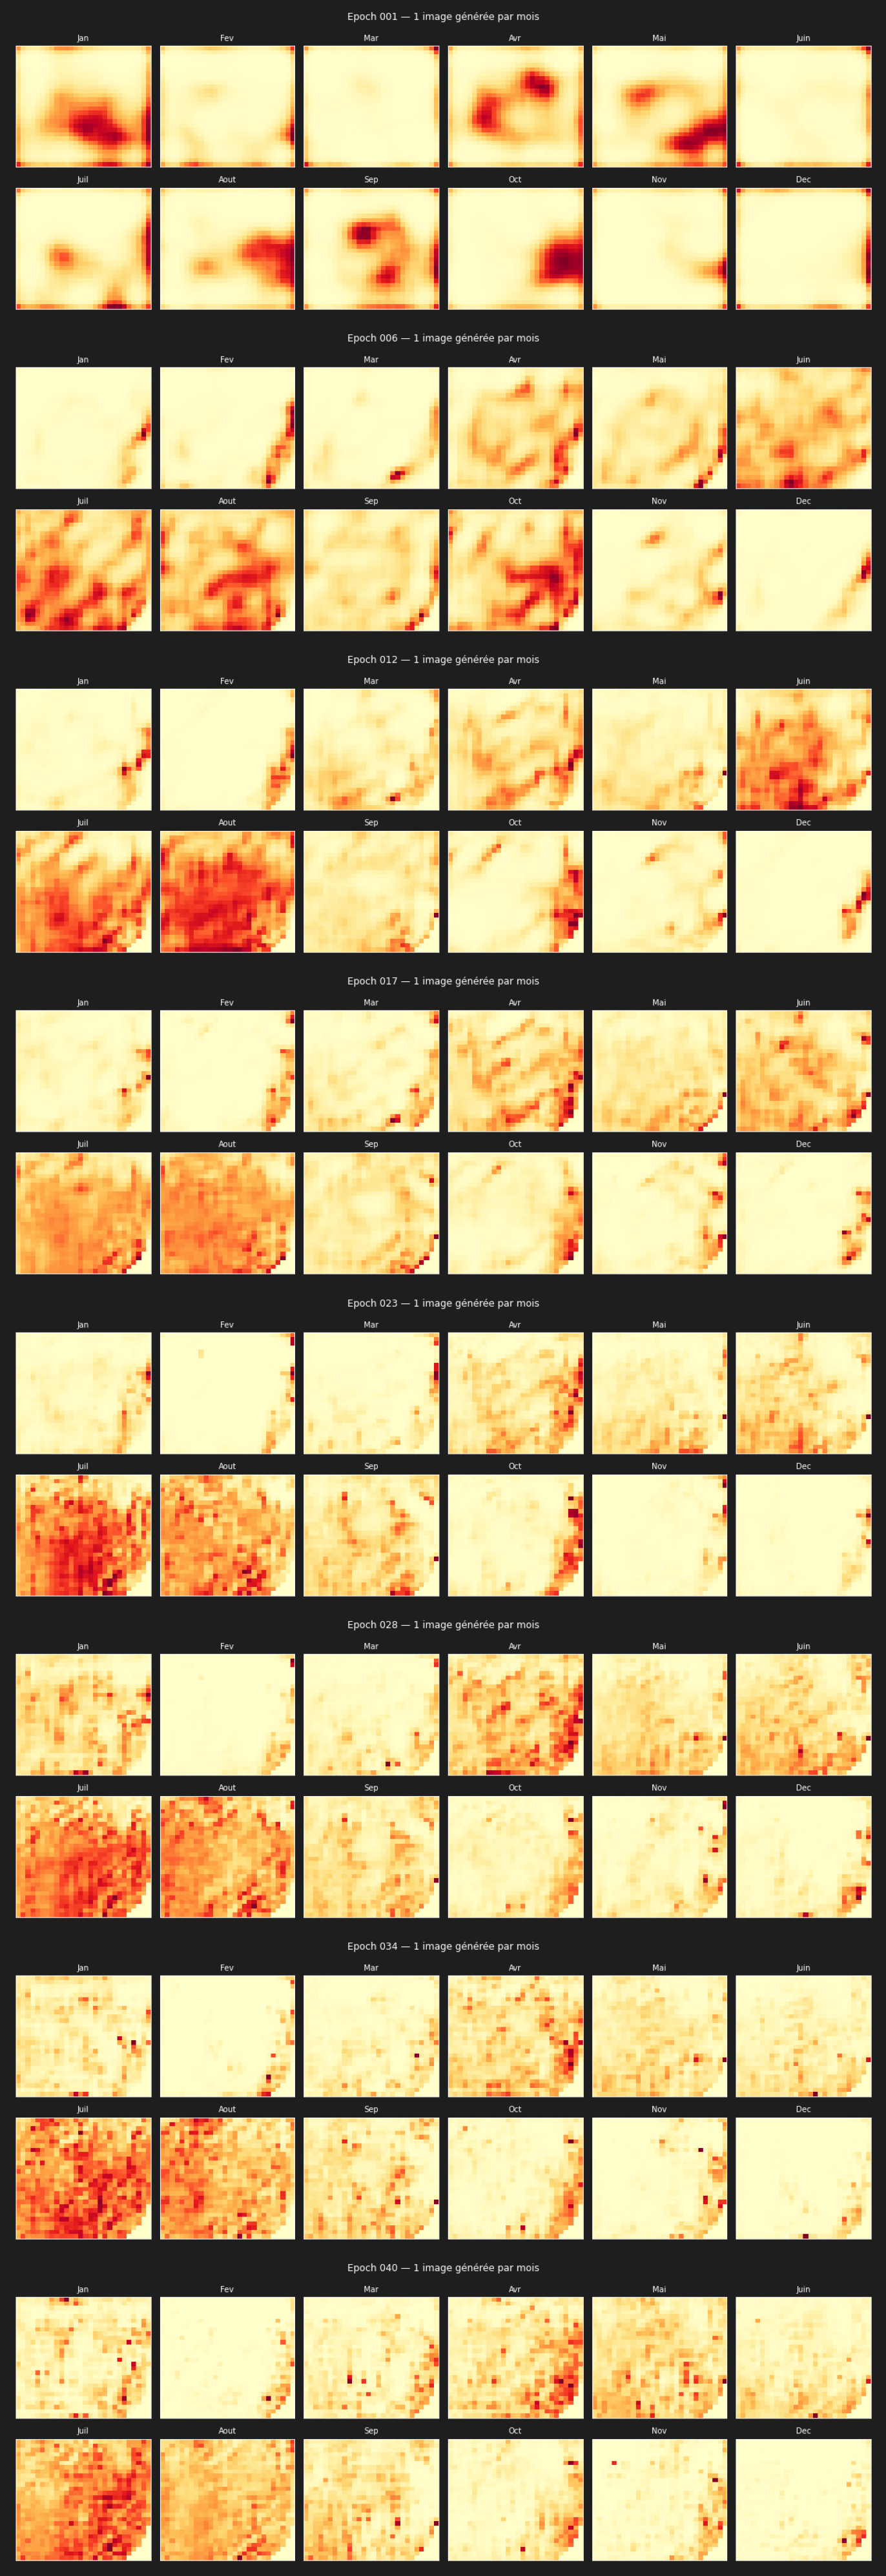

In [72]:
from matplotlib.image import imread

files = sorted([f for f in os.listdir("./run_cond_naive") if f.endswith(".png")])
n_show = min(8, len(files))
idx_show = np.linspace(0, len(files)-1, n_show, dtype=int)

fig, axes = plt.subplots(n_show, 1, figsize=(14, 5*n_show), facecolor="#1e1e1e")
if n_show == 1: axes = [axes]
for ax, k in zip(axes, idx_show):
    img = imread(f"./run_cond_naive/{files[k]}")
    ax.imshow(img); ax.axis("off")
plt.tight_layout(); plt.show()

## 7. Test : génération conditionnée vs vrais échantillons du test set

Pour chaque mois, on affiche :
- ligne 0 : un **vrai échantillon test** de ce mois
- ligne 1 : une **image générée** conditionnée sur ce même mois
- ligne 2 : la **moyenne** des images générées pour ce mois (sur 200 échantillons) — c'est ce qui devrait ressembler à la moyenne du test set du même mois

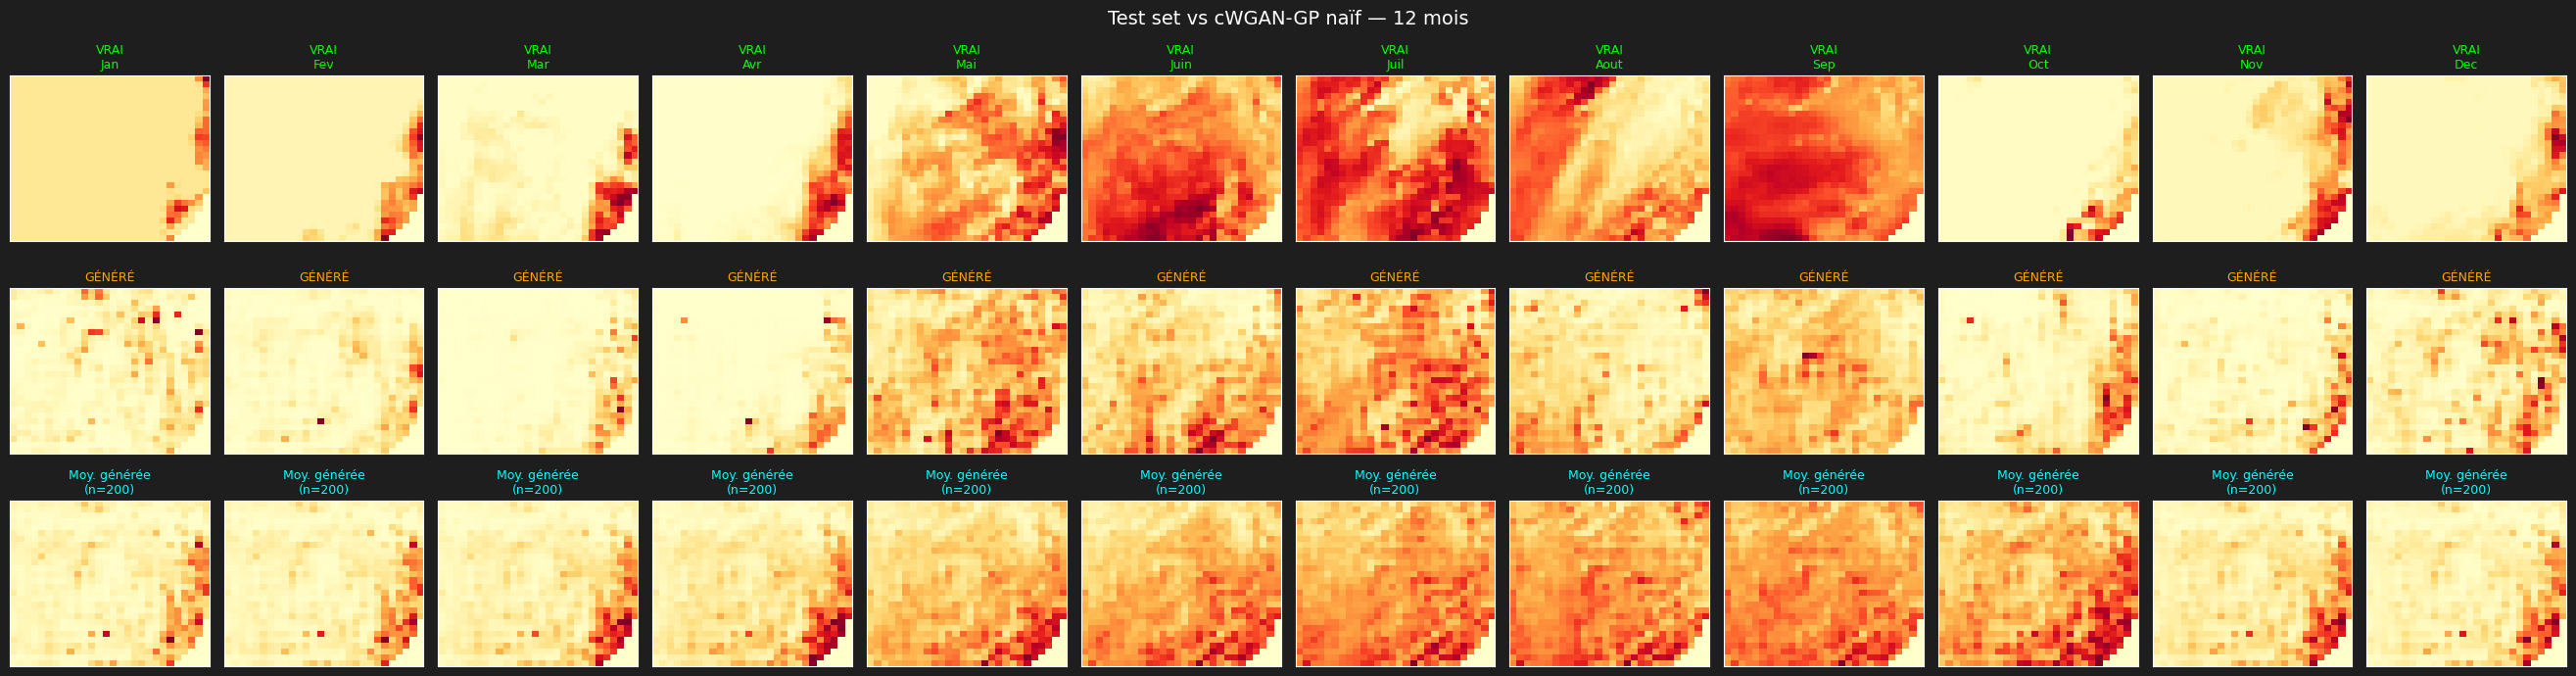

In [73]:
np.random.seed(42)
fig, axes = plt.subplots(3, N_MONTHS, figsize=(2.2*N_MONTHS, 7), facecolor="#1e1e1e")

for m in range(N_MONTHS):
    # ligne 0 : vrai test
    idx_m = np.where(y_test == m)[0]
    if len(idx_m) > 0:
        i = np.random.choice(idx_m)
        ax = axes[0, m]; ax.set_facecolor("#1e1e1e")
        ax.imshow(x_test[i, ..., 0] * x_max, cmap="YlOrRd", origin="lower",
                  extent=extent, aspect="auto")
        ax.set_title(f"VRAI\n{month_names[m]}", color="lime", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values(): s.set_color("white")
    else:
        axes[0, m].axis("off")

    # ligne 1 : 1 image générée pour ce mois
    z = tf.random.normal((1, latent_dim))
    fake = cgan.generator([z, tf.constant([m])], training=False).numpy()
    ax = axes[1, m]; ax.set_facecolor("#1e1e1e")
    ax.imshow(fake[0, ..., 0] * x_max, cmap="YlOrRd", origin="lower",
              extent=extent, aspect="auto")
    ax.set_title("GÉNÉRÉ", color="orange", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_color("white")

    # ligne 2 : moyenne sur 200 générations pour ce mois
    z200 = tf.random.normal((200, latent_dim))
    fake200 = cgan.generator(
        [z200, tf.constant([m]*200, dtype=tf.int32)],
        training=False).numpy()
    mean_fake = fake200.mean(axis=0)[..., 0] * x_max
    ax = axes[2, m]; ax.set_facecolor("#1e1e1e")
    ax.imshow(mean_fake, cmap="YlOrRd", origin="lower",
              extent=extent, aspect="auto")
    ax.set_title("Moy. générée\n(n=200)", color="cyan", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_color("white")

plt.suptitle("Test set vs cWGAN-GP naïf — 12 mois",
             color="white", fontsize=14)
plt.tight_layout(); plt.show()

### 7.1 FID conditionnel détaillé sur le test set

/var/folders/3k/gpr62wcn3h7dyfkv8l9fcsl00000gn/T/ipykernel_26075/2814829722.py:25: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = sqrtm(sigma_r @ sigma_g, disp=False)


FID conditionnel TEST (moyenne 12 mois) : 0.919

FID par mois sur le test :
  Jan   :   0.280
  Fev   :   0.078
  Mar   :   0.209
  Avr   :   0.472
  Mai   :   0.019
  Juin  :   3.793
  Juil  :   1.003
  Aout  :   0.107
  Sep   :   2.173
  Oct   :   0.141
  Nov   :   1.598
  Dec   :   1.152


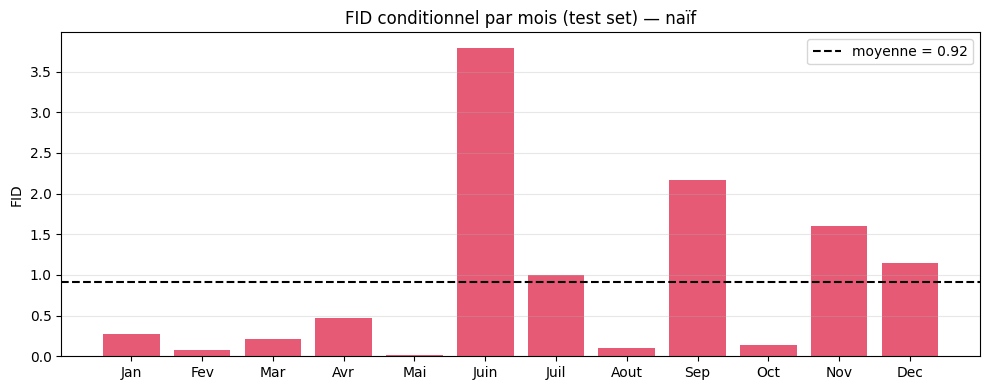

In [74]:
fid_test_mean, fid_test_per_month = compute_fid_conditional(
    cgan.generator, encoder, x_test, y_test, latent_dim, n_samples_per_class=300,
)

print(f"FID conditionnel TEST (moyenne 12 mois) : {fid_test_mean:.3f}\n")
print("FID par mois sur le test :")
for m in range(N_MONTHS):
    if m in fid_test_per_month:
        print(f"  {month_names[m]:5s} : {fid_test_per_month[m]:7.3f}")
    else:
        print(f"  {month_names[m]:5s} :  (pas assez d'echantillons valides)")

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
months_plot = [m for m in range(N_MONTHS) if m in fid_test_per_month]
fids_plot = [fid_test_per_month[m] for m in months_plot]
ax.bar([month_names[m] for m in months_plot], fids_plot, color="crimson", alpha=0.7)
ax.axhline(fid_test_mean, color="black", linestyle="--",
           label=f"moyenne = {fid_test_mean:.2f}")
ax.set_ylabel("FID")
ax.set_title("FID conditionnel par mois (test set) — naïf")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

---
## 8. Fine-tuning Bayésien avec **FID conditionnel** comme objectif

On garde la même structure de cWGAN-GP mais on cherche les meilleurs HP. **Objectif du tuner = minimiser le FID conditionnel sur le valid**.

HP recherchés :
- `latent_dim`         ∈ {16, 32, 64}
- `n_critic`           ∈ {2, 3, 5}
- `lambda_gp`          ∈ {5, 10, 20}
- `learning_rate`      ∈ [1e-4, 5e-4] (log)
- `disc_filters_1`     ∈ {8, 16, 32}
- `gen_filters_base`   ∈ {16, 32, 64}
- `embed_dim`          ∈ {8, 16, 32}
- `dropout_disc`       ∈ [0.1, 0.4]

In [ ]:
import keras_tuner as kt

def build_cwgan_gp(hp):
    ld  = hp.Choice("latent_dim",       [16, 32, 64])
    nc  = hp.Choice("n_critic",         [2, 3, 5])
    lg  = hp.Choice("lambda_gp",        [5.0, 10.0, 20.0])
    lr  = hp.Float ("learning_rate",    1e-4, 5e-4, sampling="log")
    f1  = hp.Choice("disc_filters_1",   [8, 16, 32])
    fg  = hp.Choice("gen_filters_base", [16, 32, 64])
    ed  = hp.Choice("embed_dim",        [8, 16, 32])
    dd  = hp.Float ("dropout_disc",     0.1, 0.4, step=0.1)

    # ---- Critic ----
    img_in   = keras.Input(shape=(28, 28, 1))
    label_in = keras.Input(shape=(), dtype="int32")
    e = layers.Embedding(N_MONTHS, ed)(label_in)
    e = layers.Reshape((1, 1, ed))(e)
    e = layers.UpSampling2D(size=(28, 28))(e)
    x = layers.Concatenate()([img_in, e])
    x = layers.Conv2D(f1,    4, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(f1*2,  4, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(dd)(x)
    out_d = layers.Dense(1)(x)
    disc  = keras.Model([img_in, label_in], out_d, name="cond_critic")

    # ---- Generator ----
    z_in     = keras.Input(shape=(ld,))
    label_in2= keras.Input(shape=(), dtype="int32")
    e2 = layers.Embedding(N_MONTHS, ed)(label_in2)
    h  = layers.Concatenate()([z_in, e2])
    x = layers.Dense(7*7*fg)(h)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Reshape((7, 7, fg))(x)
    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(fg,    3, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(fg//2, 3, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)
    out_g = layers.Conv2D(1, 5, padding="same", activation="sigmoid")(x)
    gen   = keras.Model([z_in, label_in2], out_g, name="cond_generator")

    model = CondWGANGP(discriminator=disc, generator=gen,
                       latent_dim=ld, n_critic=nc, lambda_gp=lg)
    model.compile(
        d_optimizer=keras.optimizers.Adam(learning_rate=lr, beta_1=0.5, beta_2=0.9),
        g_optimizer=keras.optimizers.Adam(learning_rate=lr, beta_1=0.5, beta_2=0.9),
    )
    return model

### 8.1 Tuner Bayésien custom — objectif `FID conditionnel valid`

À la fin de chaque trial, on calcule le FID conditionnel sur le valid set et on le retourne au tuner. Le tuner Bayésien va se concentrer sur les régions de l'espace HP où le FID est faible.

In [ ]:
class CGANBayesianTunerFID(kt.BayesianOptimization):
    # Tuner qui retourne le FID conditionnel sur valid comme objectif (a minimiser).

    def __init__(self, *args, encoder=None, x_valid=None, y_valid=None,
                 fid_n_per_class=200, **kwargs):
        super().__init__(*args, **kwargs)
        self._encoder = encoder
        self._x_valid = x_valid
        self._y_valid = y_valid
        self._fid_n_per_class = fid_n_per_class

    def run_trial(self, trial, *args, **kwargs):
        hp     = trial.hyperparameters
        model  = self.hypermodel.build(hp)

        # Entraine le modele 
        model.fit(*args, **kwargs)

        # Calcule le FID conditionnel sur le valid
        fid_mean, _ = compute_fid_conditional(
            model.generator, self._encoder,
            self._x_valid, self._y_valid, hp.values["latent_dim"],
            n_samples_per_class=self._fid_n_per_class,
        )
        print(f"  [trial] FID conditionnel valid = {fid_mean:.3f}")
        
        try:
            self.oracle.update_trial(trial.trial_id, {"val_fid_cond": fid_mean})
        except Exception:
            pass
        return {"val_fid_cond": fid_mean}


tuner = CGANBayesianTunerFID(
    hypermodel    = build_cwgan_gp,
    objective     = kt.Objective("val_fid_cond", direction="min"),  # minimiser le FID
    max_trials    = 8,
    num_initial_points = 3,
    directory     = "kt_cwgangp_fid",
    project_name  = "fwi_cwgangp_bayes",
    overwrite     = True,
    encoder       = encoder,
    x_valid       = x_valid,
    y_valid       = y_valid,
    fid_n_per_class = 150,  
)

tuner.search_space_summary()

Search space summary
Default search space size: 8
latent_dim (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64], 'ordered': True}
n_critic (Choice)
{'default': 2, 'conditions': [], 'values': [2, 3, 5], 'ordered': True}
lambda_gp (Choice)
{'default': 5.0, 'conditions': [], 'values': [5.0, 10.0, 20.0], 'ordered': True}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.0005, 'step': None, 'sampling': 'log'}
disc_filters_1 (Choice)
{'default': 8, 'conditions': [], 'values': [8, 16, 32], 'ordered': True}
gen_filters_base (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64], 'ordered': True}
embed_dim (Choice)
{'default': 8, 'conditions': [], 'values': [8, 16, 32], 'ordered': True}
dropout_disc (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.4, 'step': 0.1, 'sampling': 'linear'}


### 8.2 Lancement de la recherche

Chaque trial entraîne un cWGAN-GP pendant `SEARCH_EPOCHS` epochs puis évalue le FID. Pour gagner du temps on prend `SEARCH_EPOCHS=15`. Pas de callback FID intermédiaire pour éviter de tout ralentir.

In [77]:
SEARCH_EPOCHS = 15

tuner.search(
    train_ds,
    validation_data = valid_ds,
    epochs          = SEARCH_EPOCHS,
    verbose         = 1,
)

Trial 8 Complete [00h 05m 12s]
val_fid_cond: 10.674858436988094

Best val_fid_cond So Far: 0.5263031057425448
Total elapsed time: 00h 45m 27s


### 8.3 Meilleurs HP trouvés

In [78]:
tuner.results_summary(num_trials=5)

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\n=== Meilleurs hyperparamètres ===")
for k, v in best_hp.values.items():
    print(f"  {k:20s} = {v}")

Results summary
Results in kt_cwgangp_fid/fwi_cwgangp_bayes
Showing 5 best trials
Objective(name="val_fid_cond", direction="min")

Trial 6 summary
Hyperparameters:
latent_dim: 32
n_critic: 3
lambda_gp: 10.0
learning_rate: 0.00014139180255936702
disc_filters_1: 32
gen_filters_base: 16
embed_dim: 32
dropout_disc: 0.30000000000000004
Score: 0.5263031057425448

Trial 1 summary
Hyperparameters:
latent_dim: 16
n_critic: 3
lambda_gp: 20.0
learning_rate: 0.00021375755911922473
disc_filters_1: 16
gen_filters_base: 64
embed_dim: 16
dropout_disc: 0.4
Score: 0.7996417396528758

Trial 5 summary
Hyperparameters:
latent_dim: 16
n_critic: 3
lambda_gp: 20.0
learning_rate: 0.00014700099803523152
disc_filters_1: 16
gen_filters_base: 32
embed_dim: 32
dropout_disc: 0.30000000000000004
Score: 0.8596827143573441

Trial 2 summary
Hyperparameters:
latent_dim: 16
n_critic: 2
lambda_gp: 20.0
learning_rate: 0.0002416663001291767
disc_filters_1: 8
gen_filters_base: 32
embed_dim: 32
dropout_disc: 0.2
Score: 1.26039

### 8.4 Ré-entraînement final avec les meilleurs HP

On entraîne plus longtemps (40 epochs) le modèle gagnant et on suit la trajectoire FID.

In [79]:
best_cgan = tuner.hypermodel.build(best_hp)

img_cb_best = CondImagesCallback(
    latent_dim=best_hp.values["latent_dim"],
    run_dir="./run_cond_best", x_max=x_max, extent=extent,
)
fid_cb_best = FIDCallback(
    encoder, x_valid, y_valid,
    latent_dim=best_hp.values["latent_dim"],
    every=2, n_per_class=200,
)

history_best = best_cgan.fit(
    train_ds,
    validation_data = valid_ds,
    epochs          = 40,
    callbacks       = [img_cb_best, fid_cb_best],
    verbose         = 1,
)

Epoch 1/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 34s 174ms/step - d_loss: -4.1635 - g_loss: 1.8693 - w_loss: -5.2424 - val_d_loss: -1.5663 - val_g_loss: -6.4088 - val_w_loss: -1.5663
Epoch 2/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - d_loss: -1.4323 - g_loss: -5.5371 - w_loss: -1.4970

/var/folders/3k/gpr62wcn3h7dyfkv8l9fcsl00000gn/T/ipykernel_26075/2814829722.py:25: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = sqrtm(sigma_r @ sigma_g, disp=False)


  [FIDCallback] epoch 2 : FID conditionnel valid = 6.475
176/176 ━━━━━━━━━━━━━━━━━━━━ 31s 174ms/step - d_loss: -1.4038 - g_loss: -4.9091 - w_loss: -1.4810 - val_d_loss: -1.4842 - val_g_loss: -3.9005 - val_w_loss: -1.4842 - val_fid_cond: 6.4745
Epoch 3/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 28s 161ms/step - d_loss: -1.1813 - g_loss: -6.0768 - w_loss: -1.2829 - val_d_loss: -0.6790 - val_g_loss: -7.2088 - val_w_loss: -0.6790
Epoch 4/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - d_loss: -0.7485 - g_loss: -5.8701 - w_loss: -0.8072  [FIDCallback] epoch 4 : FID conditionnel valid = 2.165
176/176 ━━━━━━━━━━━━━━━━━━━━ 29s 163ms/step - d_loss: -0.6384 - g_loss: -5.2109 - w_loss: -0.6827 - val_d_loss: -0.4340 - val_g_loss: -3.5060 - val_w_loss: -0.4340 - val_fid_cond: 2.1650
Epoch 5/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 28s 159ms/step - d_loss: -0.4800 - g_loss: -5.4324 - w_loss: -0.5083 - val_d_loss: -0.4046 - val_g_loss: -6.9930 - val_w_loss: -0.4046
Epoch 6/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step -

In [80]:
generator_path = "../fwi_generator_best_cwgangp.keras"
best_cgan.generator.save(generator_path)
print(f"Générateur sauvegardé sous : {generator_path}")


Générateur sauvegardé sous : ../fwi_generator_best_cwgangp.keras


### 8.5 Loss et FID du modèle optimisé

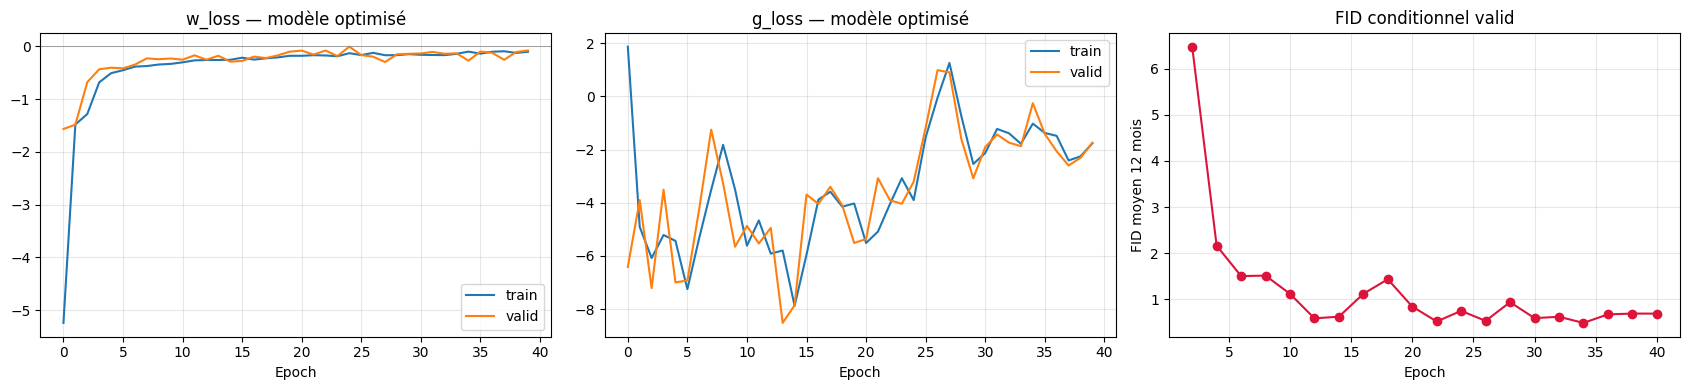

In [81]:
hb       = history_best.history
fid_log_b = fid_cb_best.fids

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].plot(hb["w_loss"],     label="train")
if "val_w_loss" in hb:
    axes[0].plot(hb["val_w_loss"], label="valid")
axes[0].set_title("w_loss — modèle optimisé")
axes[0].axhline(0, color="grey", lw=0.5)
axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hb["g_loss"],     label="train")
if "val_g_loss" in hb:
    axes[1].plot(hb["val_g_loss"], label="valid")
axes[1].set_title("g_loss — modèle optimisé")
axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

if fid_log_b:
    axes[2].plot([f["epoch"] for f in fid_log_b],
                 [f["fid_mean"] for f in fid_log_b],
                 marker="o", color="crimson")
    axes[2].set_title("FID conditionnel valid")
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("FID moyen 12 mois")
    axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

### 8.6 Comparaison finale : test vs cWGAN-GP optimisé

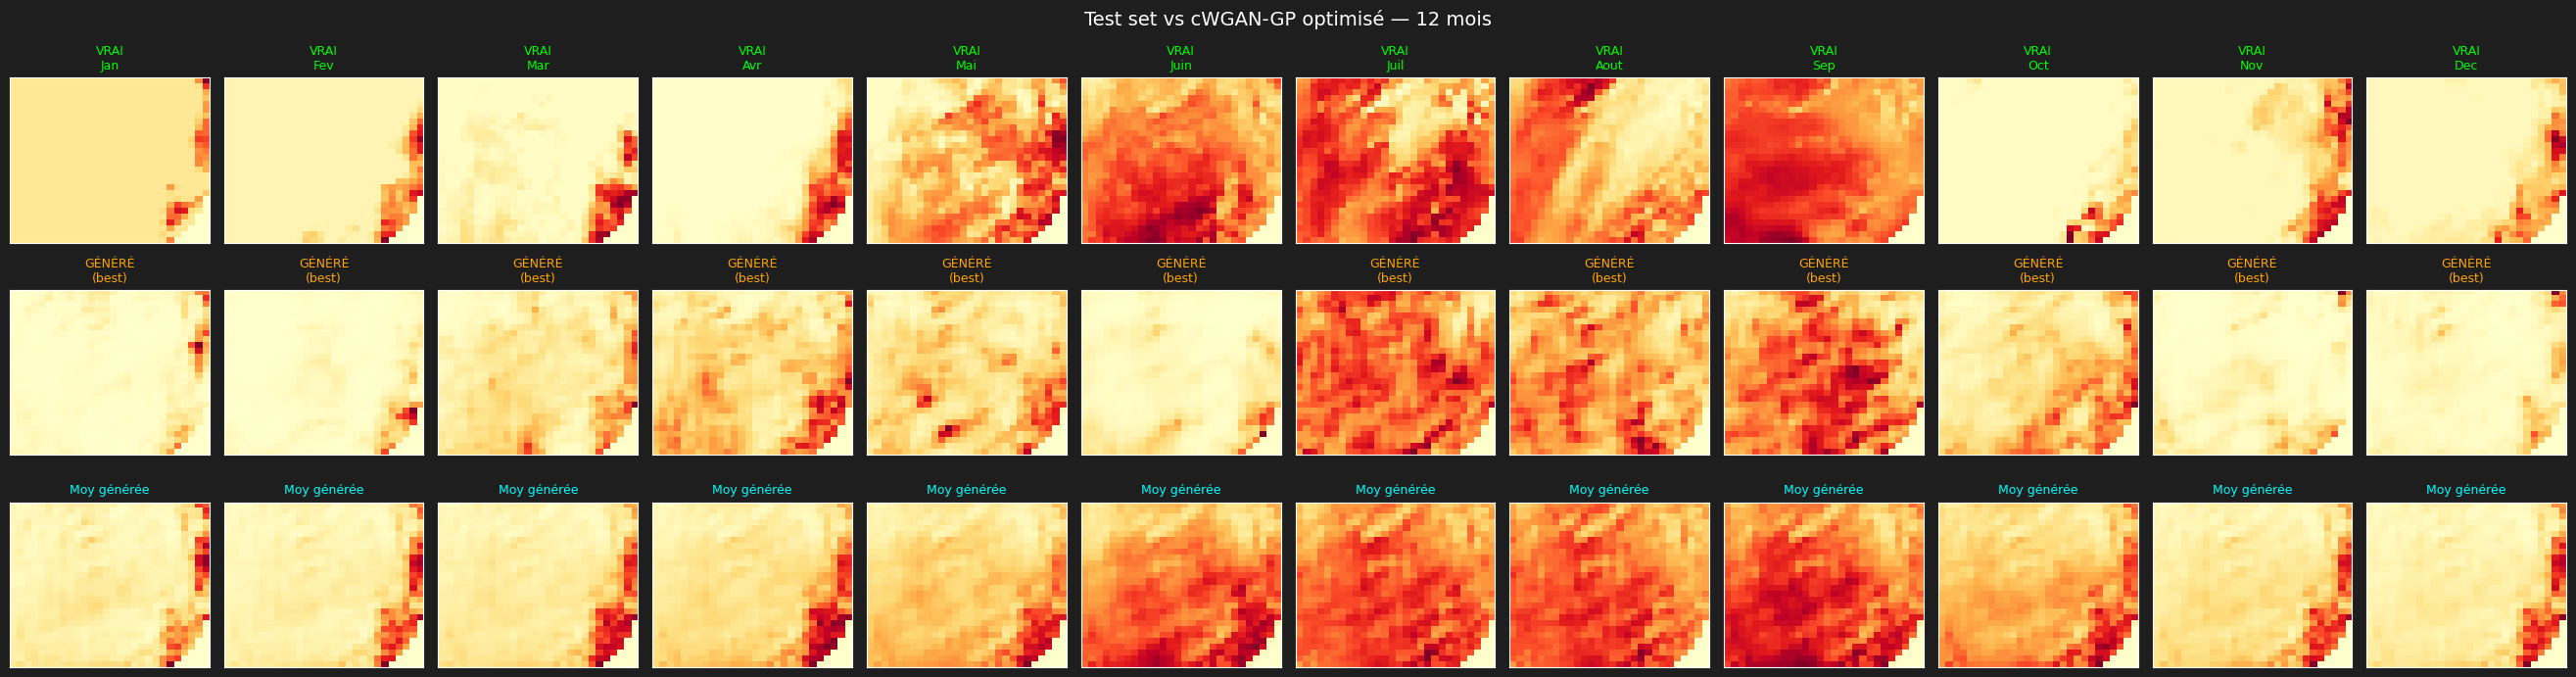

/var/folders/3k/gpr62wcn3h7dyfkv8l9fcsl00000gn/T/ipykernel_26075/2814829722.py:25: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = sqrtm(sigma_r @ sigma_g, disp=False)



FID conditionnel TEST — naïf    : 0.919
FID conditionnel TEST — optimisé : 1.058


In [82]:
ld_best = best_hp.values["latent_dim"]

np.random.seed(42)
fig, axes = plt.subplots(3, N_MONTHS, figsize=(2.2*N_MONTHS, 7), facecolor="#1e1e1e")

for m in range(N_MONTHS):
    # ligne 0 : vrai test
    idx_m = np.where(y_test == m)[0]
    if len(idx_m) > 0:
        i = np.random.choice(idx_m)
        ax = axes[0, m]; ax.set_facecolor("#1e1e1e")
        ax.imshow(x_test[i, ..., 0] * x_max, cmap="YlOrRd", origin="lower",
                  extent=extent, aspect="auto")
        ax.set_title(f"VRAI\n{month_names[m]}", color="lime", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values(): s.set_color("white")
    else:
        axes[0, m].axis("off")

    # ligne 1 : 1 image générée
    z = tf.random.normal((1, ld_best))
    fake = best_cgan.generator([z, tf.constant([m])], training=False).numpy()
    ax = axes[1, m]; ax.set_facecolor("#1e1e1e")
    ax.imshow(fake[0, ..., 0] * x_max, cmap="YlOrRd", origin="lower",
              extent=extent, aspect="auto")
    ax.set_title("GÉNÉRÉ\n(best)", color="orange", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_color("white")

    # ligne 2 : moyenne 200
    z200 = tf.random.normal((200, ld_best))
    fake200 = best_cgan.generator(
        [z200, tf.constant([m]*200, dtype=tf.int32)], training=False).numpy()
    mean_fake = fake200.mean(axis=0)[..., 0] * x_max
    ax = axes[2, m]; ax.set_facecolor("#1e1e1e")
    ax.imshow(mean_fake, cmap="YlOrRd", origin="lower",
              extent=extent, aspect="auto")
    ax.set_title("Moy générée", color="cyan", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_color("white")

plt.suptitle("Test set vs cWGAN-GP optimisé — 12 mois",
             color="white", fontsize=14)
plt.tight_layout(); plt.show()

# FID test du modele optimise
fid_test_mean_best, fid_test_per_month_best = compute_fid_conditional(
    best_cgan.generator, encoder, x_test, y_test, ld_best, n_samples_per_class=300,
)
print(f"\nFID conditionnel TEST — naïf    : {fid_test_mean:.3f}")
print(f"FID conditionnel TEST — optimisé : {fid_test_mean_best:.3f}")

### 8.7 Comparaison FID par mois : naïf vs optimisé

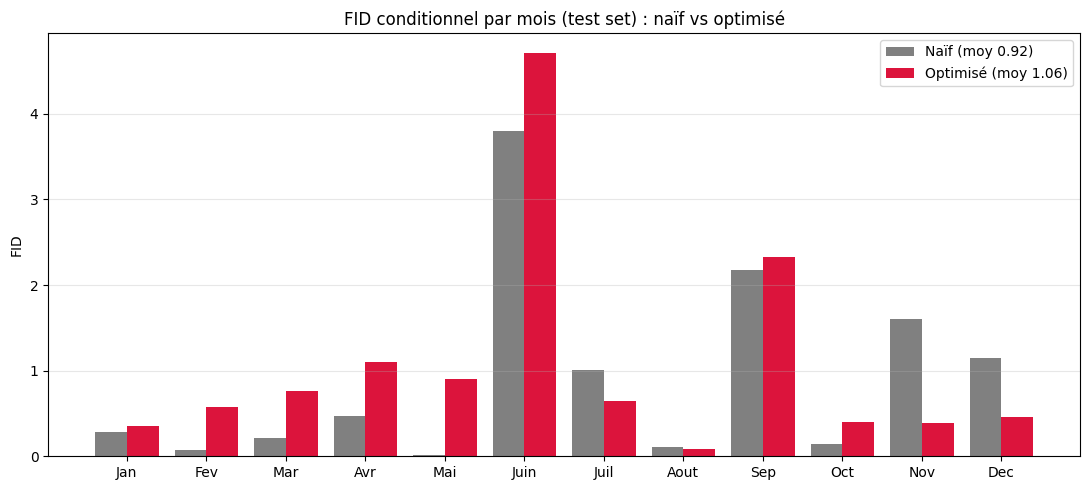

In [83]:
fig, ax = plt.subplots(figsize=(11, 5))
xpos = np.arange(N_MONTHS)
w = 0.4

naive_vals = [fid_test_per_month     .get(m, np.nan) for m in range(N_MONTHS)]
best_vals  = [fid_test_per_month_best.get(m, np.nan) for m in range(N_MONTHS)]

ax.bar(xpos - w/2, naive_vals, w, label=f"Naïf (moy {fid_test_mean:.2f})",      color="grey")
ax.bar(xpos + w/2, best_vals,  w, label=f"Optimisé (moy {fid_test_mean_best:.2f})", color="crimson")
ax.set_xticks(xpos)
ax.set_xticklabels(month_names)
ax.set_ylabel("FID")
ax.set_title("FID conditionnel par mois (test set) : naïf vs optimisé")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()